<a href="https://colab.research.google.com/github/Maria54-star/NOVO-GRAFICO-DA-COPA-DO-MUNDO-2026/blob/main/Copadomundo_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

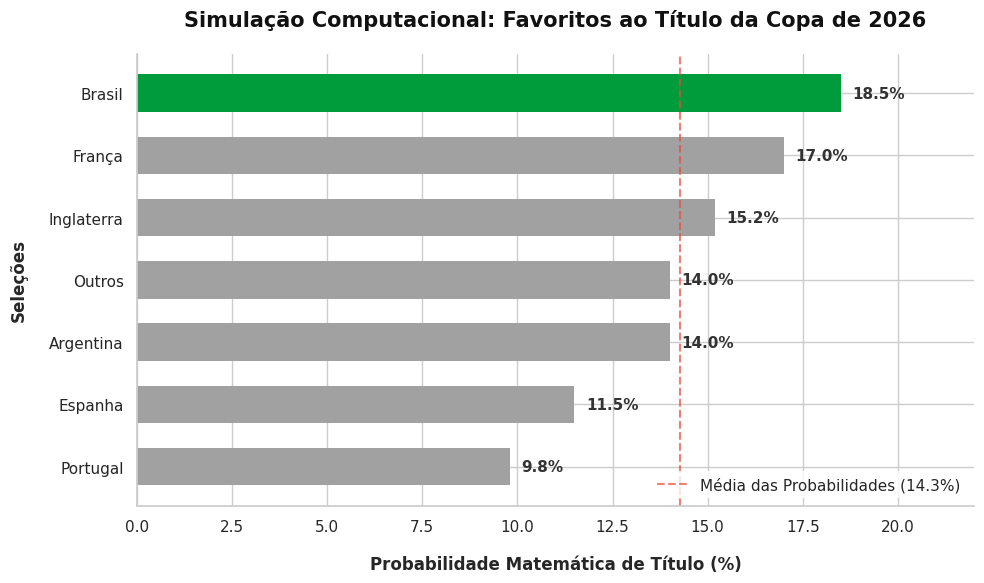

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Configuração dos dados da simulação da Copa de 2026
dados = {
    "Seleção": [
        "Brasil",
        "França",
        "Inglaterra",
        "Argentina",
        "Espanha",
        "Portugal",
        "Outros",
    ],
    "Probabilidade (%)": [18.5, 17.0, 15.2, 14.0, 11.5, 9.8, 14.0],
}

df = pd.DataFrame(dados)
df = df.sort_values(by="Probabilidade (%)", ascending=True)

# 2. Configuração do estilo visual profissional
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

# Definição de cores: Destaque para o Brasil (favorito), cinza para os outros
cores = [
    "#A1A1A1" if x != "Brasil" else "#009c3b" for x in df["Seleção"]
]  # Verde para o Brasil

# 3. Construção do gráfico de barras horizontais
barras = ax.barh(
    df["Seleção"],
    df["Probabilidade (%)"],
    color=cores,
    edgecolor="none",
    height=0.6,
)

# 4. Adicionar os valores percentuais ao lado das barras
for barra in barras:
    width = barra.get_width()
    ax.text(
        width + 0.3,  # Posição X
        barra.get_y() + barra.get_height() / 2,  # Posição Y
        f"{width:.1f}%",  # Texto
        ha="left",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="#333333",
    )

# 5. Refinamento estético (Eliminar bordas desnecessárias)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#cccccc")
ax.spines["bottom"].set_color("#cccccc")

# Ajustar limites e rótulos
ax.set_xlim(0, 22)
ax.set_xlabel(
    "Probabilidade Matemática de Título (%)",
    fontsize=12,
    fontweight="bold",
    labelpad=15,
)
ax.set_ylabel("Seleções", fontsize=12, fontweight="bold", labelpad=15)
ax.set_title(
    "Simulação Computacional: Favoritos ao Título da Copa de 2026",
    fontsize=15,
    fontweight="bold",
    pad=20,
    color="#111111",
)

# Linha vertical discreta indicando a média das potências principais
media_prob = df["Probabilidade (%)"].mean()
ax.axvline(
    media_prob,
    color="#e74c3c",
    linestyle="--",
    alpha=0.7,
    label=f"Média das Probabilidades ({media_prob:.1f}%)",
)
ax.legend(loc="lower right", frameon=True, facecolor="white", edgecolor="none")

plt.tight_layout()

# Exibir o gráfico no Colab
plt.show()

In [ ]:
import numpy as np
import pandas as pd

# 1. Recriando o DataFrame para garantir que a célula rode de forma independente
dados = {
    "Seleção": [
        "Brasil",
        "França",
        "Inglaterra",
        "Argentina",
        "Espanha",
        "Portugal",
        "Outros",
    ],
    "Probabilidade (%)": [18.5, 17.0, 15.2, 14.0, 11.5, 9.8, 14.0],
}
df = pd.DataFrame(dados)

# Ordenar do maior para o menor para a análise descritiva
df = df.sort_values(by="Probabilidade (%)", ascending=False).reset_index(
    drop=True
)

print("-" * 60)
print("       RELATÓRIO ANALÍTICO: PROJEÇÃO COPA DO MUNDO 2026       ")
print("-" * 60)

# INSIGHT 1: Identificação Automatizada do Líder e sua Vantagem
lider = df.iloc[0]["Seleção"]
prob_lider = df.iloc[0]["Probabilidade (%)"]
segundo = df.iloc[1]["Seleção"]
prob_segundo = df.iloc[1]["Probabilidade (%)"]
distancia_segundo = prob_lider - prob_segundo

print(f"[INSIGHT 1: LIDERANÇA E MARGEM DE VANTAGEM]")
print(f"• A seleção favorita ao título é o {lider} com {prob_lider}%.")
print(
    f"• A vantagem para a segunda colocada ({segundo}, {prob_segundo}%) é de apenas {distancia_segundo:.1f} pontos percentuais."
)
print(
    f"• Implicação: O modelo indica alta volatilidade. Não há um favorito absoluto; o cenário é de equilíbrio extremo."
)
print("-" * 60)

# INSIGHT 2: Métrica de Concentração (Top 3 Potências)
top_3_soma = df.iloc[0:3]["Probabilidade (%)"].sum()
print(f"[INSIGHT 2: CONCENTRAÇÃO DE FORÇA (TOP 3)]")
print(
    f"• As 3 principais seleções ({df.iloc[0]['Seleção']}, {df.iloc[1]['Seleção']} e {df.iloc[2]['Seleção']}) acumulam {top_3_soma:.1f}% de chance de título."
)
print(
    f"• Implicação: Há uma concentração de mais de metade das chances de título (excluindo a cauda longa de zebras) em apenas três eixos táticos."
)
print("-" * 60)

# INSIGHT 3: Análise da Dispersão e Distância do Pelotão (Média)
# Desconsiderando o grupo 'Outros' para avaliar apenas as potências nominais
potencias = df[df["Seleção"] != "Outros"]
media_potencias = potencias["Probabilidade (%)"].mean()

print(f"[INSIGHT 3: DISPERSÃO DO PELOTÃO PRINCIPAL]")
print(
    f"• A probabilidade média entre as potências mundiais analisadas é de {media_potencias:.1f}%."
)
print(f"• Seleções ACIMA da média: {', '.join(potencias[potencias['Probabilidade (%)'] > media_potencias]['Seleção'].tolist())}")
print(f"• Seleções ABAIXO da média: {', '.join(potencias[potencias['Probabilidade (%)'] < media_potencias]['Seleção'].tolist())}")
print("-" * 60)

# INSIGHT 4: Risco de 'Zebras' (Análise Estatística da Cauda Longa)
prob_outros = df[df["Seleção"] == "Outros"]["Probabilidade (%)"].values[0]
print(f"[INSIGHT 4: O FATOR IMPREVISIBILIDADE]")
print(
    f"• O grupo de seleções consideradas 'zebras' ou 'azarões' (Outros) detém {prob_outros}% de chance de vitória."
)
print(
    f"• Matematicamente, a chance de uma surpresa vencer a Copa é maior do que a chance individual de Portugal ({df[df['Seleção'] == 'Portugal']['Probabilidade (%)'].values[0]}%)."
)
print("-" * 60)

------------------------------------------------------------
       RELATÓRIO ANALÍTICO: PROJEÇÃO COPA DO MUNDO 2026       
------------------------------------------------------------
[INSIGHT 1: LIDERANÇA E MARGEM DE VANTAGEM]
• A seleção favorita ao título é o Brasil com 18.5%.
• A vantagem para a segunda colocada (França, 17.0%) é de apenas 1.5 pontos percentuais.
• Implicação: O modelo indica alta volatilidade. Não há um favorito absoluto; o cenário é de equilíbrio extremo.
------------------------------------------------------------
[INSIGHT 2: CONCENTRAÇÃO DE FORÇA (TOP 3)]
• As 3 principais seleções (Brasil, França e Inglaterra) acumulam 50.7% de chance de título.
• Implicação: Há uma concentração de mais de metade das chances de título (excluindo a cauda longa de zebras) em apenas três eixos táticos.
------------------------------------------------------------
[INSIGHT 3: DISPERSÃO DO PELOTÃO PRINCIPAL]
• A probabilidade média entre as potências mundiais analisadas é de 14.3%.